# NB - YOLO + Vision Transformer

Pipeline: YOLO crop vùng bệnh rồi train ViT trên ảnh crop.

In [1]:
# 1. INSTALL
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 109.7 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible

In [2]:
# 2. IMPORT

import os
import json
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report

from ultralytics import YOLO

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

2026-05-30 05:31:17.381560: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780119077.613747      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780119077.688724      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780119078.261533      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780119078.261573      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780119078.261576      58 computation_placer.cc:177] computation placer alr

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# 3. CONFIG

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_PATH = "/kaggle/input/datasets/kimlonkkk/data10k-v2/split_dataset_backup_10k_v2"

YOLO_MODEL_PATH = "/kaggle/input/datasets/kimlonkkk/best-yolo1/best_yolo_v17.pt"


IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 40

MODEL_NAME = "YOLO_ViT"
OUT_DIR = f"/kaggle/working/{MODEL_NAME}_results"
CROP_DATASET_DIR = "/kaggle/working/yolo_crop_classification_dataset"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CROP_DATASET_DIR, exist_ok=True)

AUTOTUNE = tf.data.AUTOTUNE

In [4]:
# 4. CHECK PATHS

print("DATASET_PATH exists:", os.path.exists(DATASET_PATH))
print("YOLO_MODEL_PATH exists:", os.path.exists(YOLO_MODEL_PATH))
print("Dataset folders:", os.listdir(DATASET_PATH))

DATASET_PATH exists: True
YOLO_MODEL_PATH exists: True
Dataset folders: ['val', 'test', 'train']


In [5]:
# 5. LOAD YOLO MODEL

yolo_model = YOLO(YOLO_MODEL_PATH)
print("YOLO classes:", yolo_model.names)

YOLO classes: {0: 'blight', 1: 'common_rust', 2: 'gray_spot', 3: 'health'}


In [6]:
# 6. CROP FUNCTION

def crop_with_yolo(image_path, yolo_model, conf_thres=0.25, img_size=224):
    image = Image.open(image_path).convert("RGB")
    w, h = image.size

    results = yolo_model.predict(
        source=str(image_path),
        conf=conf_thres,
        verbose=False
    )

    boxes = results[0].boxes

    if boxes is not None and len(boxes) > 0:
        confs = boxes.conf.cpu().numpy()
        best_idx = int(np.argmax(confs))
        xyxy = boxes.xyxy[best_idx].cpu().numpy()
        x1, y1, x2, y2 = xyxy

        pad_x = int((x2 - x1) * 0.15)
        pad_y = int((y2 - y1) * 0.15)

        x1 = max(0, int(x1) - pad_x)
        y1 = max(0, int(y1) - pad_y)
        x2 = min(w, int(x2) + pad_x)
        y2 = min(h, int(y2) + pad_y)

        if x2 > x1 and y2 > y1:
            image = image.crop((x1, y1, x2, y2))

    image = image.resize((img_size, img_size))
    return image

In [7]:
# 7. CREATE CROPPED DATASET

splits = ["train", "val", "test"]
image_exts = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

crop_stats = {"total": 0, "saved": 0, "errors": 0}

for split in splits:
    split_dir = Path(DATASET_PATH) / split

    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue

        class_name = class_dir.name
        out_class_dir = Path(CROP_DATASET_DIR) / split / class_name
        out_class_dir.mkdir(parents=True, exist_ok=True)

        image_paths = [p for p in class_dir.iterdir() if p.suffix.lower() in image_exts]
        print(f"Processing {split}/{class_name}: {len(image_paths)} images")

        for img_path in image_paths:
            crop_stats["total"] += 1

            try:
                cropped = crop_with_yolo(
                    image_path=img_path,
                    yolo_model=yolo_model,
                    conf_thres=0.25,
                    img_size=IMG_SIZE
                )

                out_path = out_class_dir / img_path.name
                cropped.save(out_path)
                crop_stats["saved"] += 1

            except Exception as e:
                crop_stats["errors"] += 1
                print("Error:", img_path, e)

print("Crop stats:", crop_stats)
print("Cropped dataset saved at:", CROP_DATASET_DIR)

Processing train/common_rust: 1261 images
Processing train/not_corn_leaf: 1690 images
Processing train/blight: 1283 images
Processing train/healthy: 1173 images
Processing train/gray_spot: 1483 images
Processing val/common_rust: 270 images
Processing val/not_corn_leaf: 362 images
Processing val/blight: 275 images
Processing val/healthy: 251 images
Processing val/gray_spot: 317 images
Processing test/common_rust: 271 images
Processing test/not_corn_leaf: 363 images
Processing test/blight: 276 images
Processing test/healthy: 253 images
Processing test/gray_spot: 319 images
Crop stats: {'total': 9847, 'saved': 9847, 'errors': 0}
Cropped dataset saved at: /kaggle/working/yolo_crop_classification_dataset


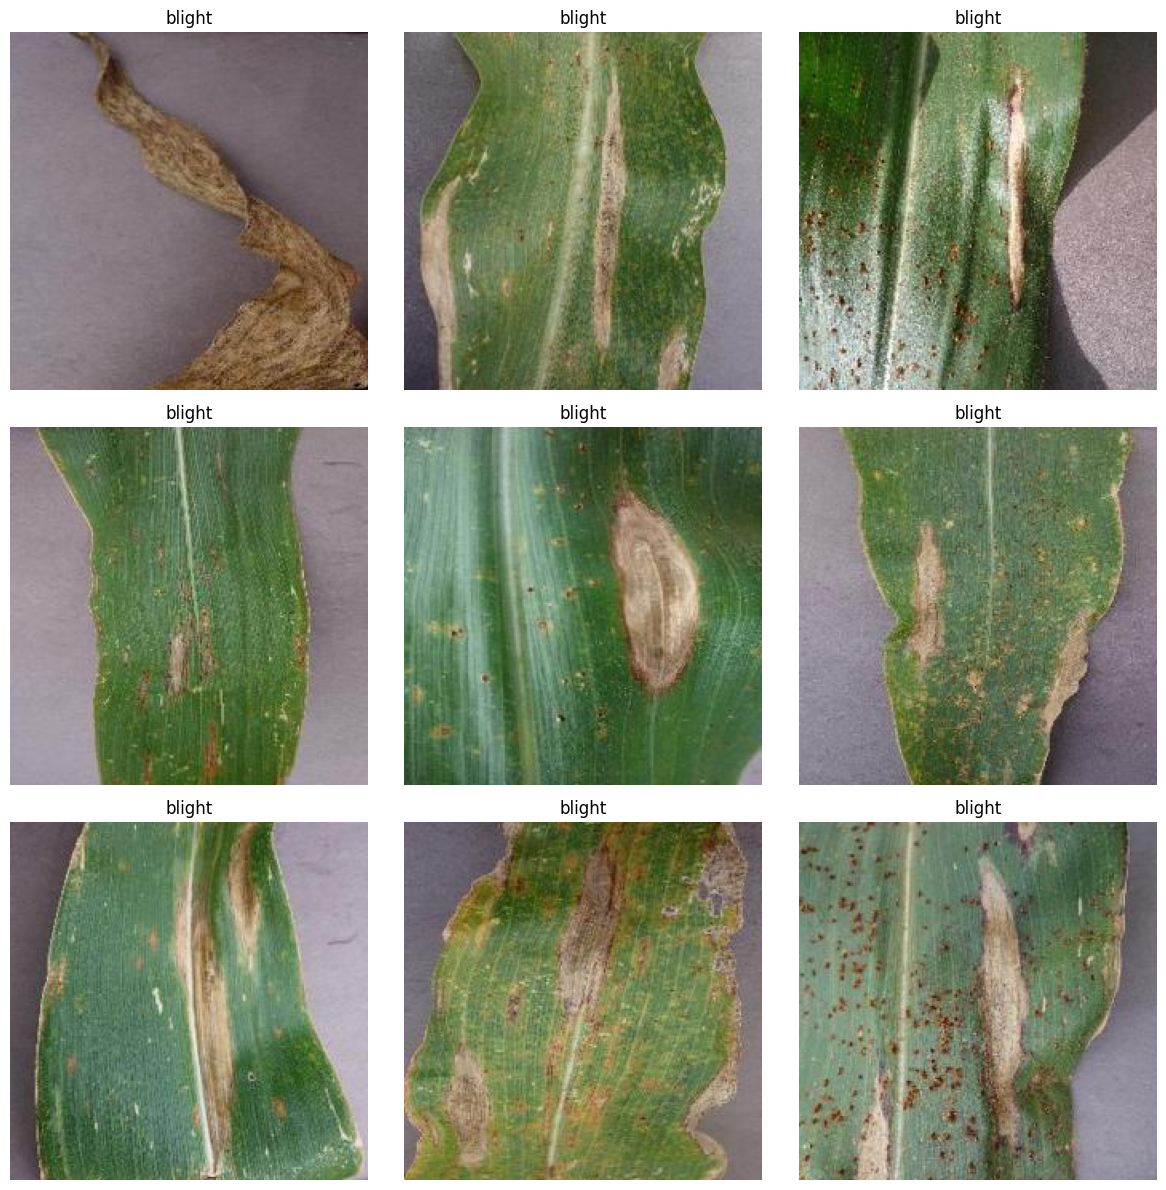

In [8]:
# 8. VISUALIZE CROPPED IMAGES

import glob

sample_images = glob.glob(CROP_DATASET_DIR + "/train/*/*")[:9]

plt.figure(figsize=(12, 12))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path).convert("RGB")

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(Path(img_path).parent.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# 9. LOAD CROPPED DATASET

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(CROP_DATASET_DIR, "train"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(CROP_DATASET_DIR, "val"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(CROP_DATASET_DIR, "test"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Num classes:", NUM_CLASSES)

Found 6890 files belonging to 5 classes.


I0000 00:00:1780119370.568477      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13677 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780119370.573569      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1475 files belonging to 5 classes.
Found 1482 files belonging to 5 classes.
Classes: ['blight', 'common_rust', 'gray_spot', 'healthy', 'not_corn_leaf']
Num classes: 5


In [10]:
# 10. NORMALIZE + PREFETCH

normalization_layer = layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [11]:
# 11. DATA AUGMENTATION NHẸ

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomZoom(0.03),
        layers.RandomTranslation(0.02, 0.02),
    ],
    name="data_augmentation"
)

In [12]:
# 12. PATCH LAYER

class Patches(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )

        patch_dims = tf.shape(patches)[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config

In [13]:
# 13. PATCH ENCODER

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim

        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim
        })
        return config

In [14]:
# 14. MLP HELPER

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

In [15]:
# 15. BUILD ViT MODEL

PATCH_SIZE = 32
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2

PROJECTION_DIM = 32
NUM_HEADS = 2
TRANSFORMER_LAYERS = 4

TRANSFORMER_UNITS = [PROJECTION_DIM * 2, PROJECTION_DIM]
MLP_HEAD_UNITS = [128]

def build_vit_model():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)

    patches = Patches(PATCH_SIZE, name="patches")(x)

    encoded_patches = PatchEncoder(
        NUM_PATCHES,
        PROJECTION_DIM,
        name="patch_encoder"
    )(patches)

    for i in range(TRANSFORMER_LAYERS):
        x1 = layers.LayerNormalization(epsilon=1e-6, name=f"ln_1_block_{i+1}")(encoded_patches)

        attention_output = layers.MultiHeadAttention(
            num_heads=NUM_HEADS,
            key_dim=PROJECTION_DIM,
            dropout=0.1,
            name=f"mha_block_{i+1}"
        )(x1, x1)

        x2 = layers.Add(name=f"skip_1_block_{i+1}")([attention_output, encoded_patches])

        x3 = layers.LayerNormalization(epsilon=1e-6, name=f"ln_2_block_{i+1}")(x2)

        x3 = mlp(x3, hidden_units=TRANSFORMER_UNITS, dropout_rate=0.1)

        encoded_patches = layers.Add(name=f"skip_2_block_{i+1}")([x3, x2])

    representation = layers.LayerNormalization(epsilon=1e-6, name="encoder_norm")(encoded_patches)
    representation = layers.Flatten(name="flatten")(representation)
    representation = layers.Dropout(0.3, name="head_dropout")(representation)

    features = mlp(representation, hidden_units=MLP_HEAD_UNITS, dropout_rate=0.3)

    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="classification_head")(features)

    model = Model(inputs=inputs, outputs=outputs, name=MODEL_NAME)
    return model

model = build_vit_model()
model.summary()

Model: "YOLO_ViT"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None,      │          0 │ data_augmentatio… │
│                     │ 3072)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 49, 32)    │     99,904 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_1_block_1        │ (None, 49, 32)    │         64 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha_block_1         │ (None, 49, 32)    │      8,416 │ ln_1_block_1[0][… │
│ (MultiHeadAttentio… │                   │            │ ln_1_block_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_1_block_1      │ (None, 49, 32)    │          0 │ mha_block_1[0][0… │
│ (Add)               │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_2_block_1        │ (None, 49, 32)    │         64 │ skip_1_block_1[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 49, 64)    │      2,112 │ ln_2_block_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 49, 64)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 49, 32)    │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 49, 32)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_2_block_1      │ (None, 49, 32)    │          0 │ dropout_2[0][0],  │
│ (Add)               │                   │            │ skip_1_block_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_1_block_2        │ (None, 49, 32)    │         64 │ skip_2_block_1[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha_block_2         │ (None, 49, 32)    │      8,416 │ ln_1_block_2[0][… │
│ (MultiHeadAttentio… │                   │            │ ln_1_block_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_1_block_2      │ (None, 49, 32)    │          0 │ mha_block_2[0][0… │
│ (Add)               │                   │            │ skip_2_block_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_2_block_2        │ (None, 49, 32)    │         64 │ skip_1_block_2[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 49, 64)    │      2,112 │ ln_2_block_2[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 352,389 (1.34 MB)

 Trainable params: 352,389 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# 16. COMPILE

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
# 17. CALLBACKS

checkpoint = ModelCheckpoint(
    filepath=f"{OUT_DIR}/{MODEL_NAME}_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint, earlystop, reduce_lr]

blight 5


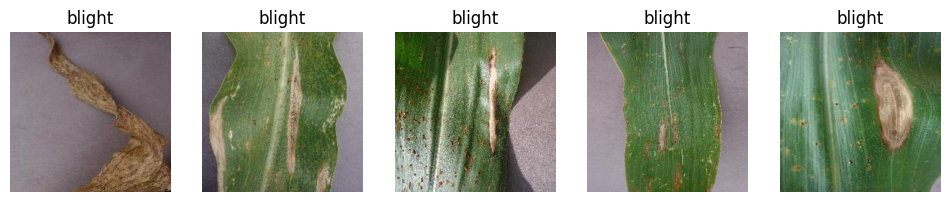

common_rust 5


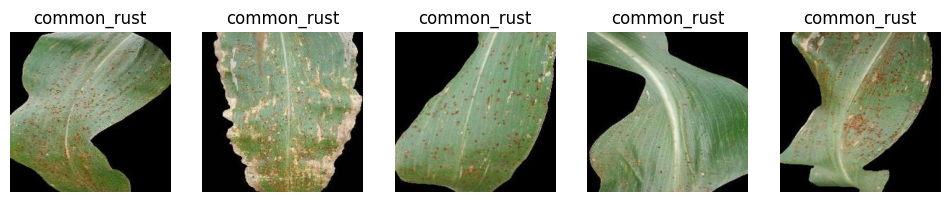

gray_spot 5


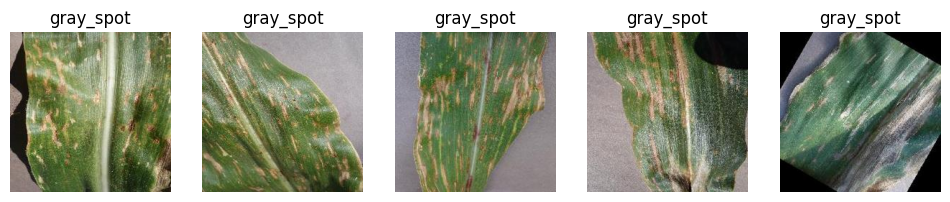

healthy 5


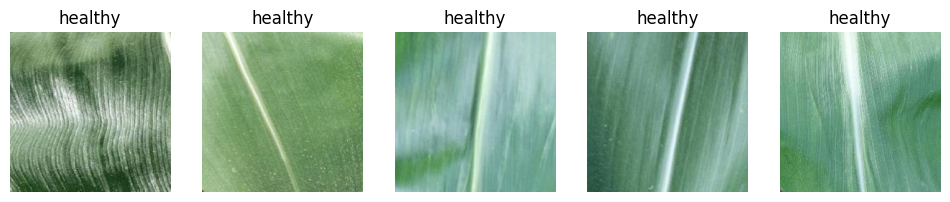

not_corn_leaf 5


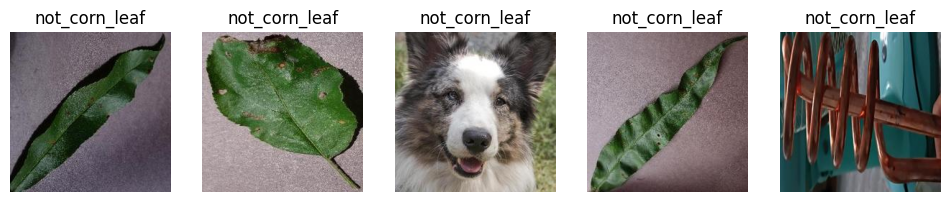

In [18]:
import glob, os
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

for cls in CLASS_NAMES:
    imgs = glob.glob(f"{CROP_DATASET_DIR}/train/{cls}/*")[:5]
    print(cls, len(imgs))

    plt.figure(figsize=(12, 3))
    for i, p in enumerate(imgs):
        img = Image.open(p).convert("RGB")
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
    plt.show()

In [19]:
# 18. TRAIN

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/40
214/216 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3635 - loss: 1.4944
Epoch 1: val_accuracy improved from None to 0.55186, saving model to /kaggle/working/YOLO_ViT_results/YOLO_ViT_best.keras

Epoch 1: finished saving model to /kaggle/working/YOLO_ViT_results/YOLO_ViT_best.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - accuracy: 0.4222 - loss: 1.2626 - val_accuracy: 0.5519 - val_loss: 0.9795 - learning_rate: 0.0010
Epoch 2/40
214/216 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6022 - loss: 0.9184
Epoch 2: val_accuracy improved from 0.55186 to 0.76542, saving model to /kaggle/working/YOLO_ViT_results/YOLO_ViT_best.keras

Epoch 2: finished saving model to /kaggle/working/YOLO_ViT_results/YOLO_ViT_best.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.6586 - loss: 0.7986 - val_accuracy: 0.7654 - val_loss: 0.5554 - learning_rate: 0.0010
Epoch 3/40
214/216 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7241 - loss: 0.6863
Epoch 3: val_accuracy improved 

In [20]:
# 19. SAVE HISTORY

history_df = pd.DataFrame(history.history)
history_path = f"{OUT_DIR}/history.csv"
history_df.to_csv(history_path, index=False)

print("Saved:", history_path)
history_df.head()

Saved: /kaggle/working/YOLO_ViT_results/history.csv


,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.422206,1.262624,0.551864,0.979513,0.001
1,0.658636,0.798643,0.765424,0.555409,0.001
2,0.752975,0.608319,0.808814,0.486598,0.001
3,0.812627,0.481592,0.855593,0.353468,0.001
4,0.829173,0.425308,0.880678,0.319349,0.001


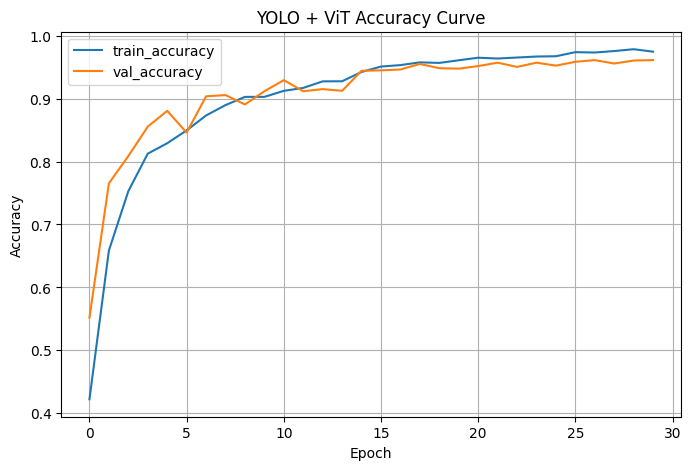

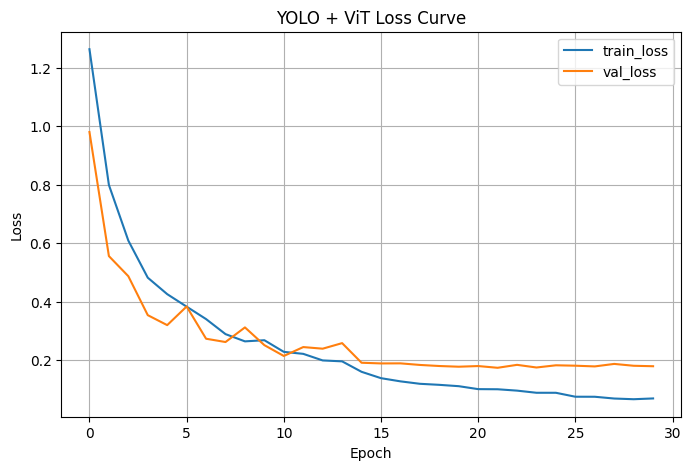

In [21]:
# 20. LEARNING CURVES

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("YOLO + ViT Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUT_DIR}/accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("YOLO + ViT Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUT_DIR}/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# 21. EVALUATE TEST SET

test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9332 - loss: 0.2328
Test Loss: 0.2328006625175476
Test Accuracy: 0.9331983923912048


In [23]:
# 22. PREDICT TEST SET

y_true = []

for _, y_batch in test_ds:
    y_true.extend(y_batch.numpy())

y_true = np.array(y_true)

pred_probs = model.predict(test_ds)
y_pred = np.argmax(pred_probs, axis=1)

print("y_true:", y_true.shape)
print("y_pred:", y_pred.shape)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
y_true: (1482,)
y_pred: (1482,)


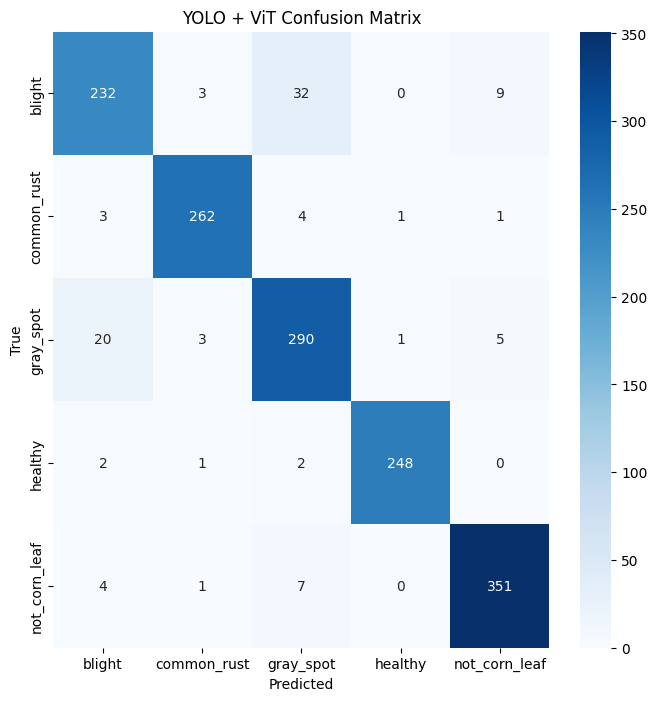

Saved: /kaggle/working/YOLO_ViT_results/confusion_matrix.png


In [24]:
# 23. CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("YOLO + ViT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

cm_path = f"{OUT_DIR}/confusion_matrix.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", cm_path)

In [25]:
# 24. CLASSIFICATION REPORT

report_text = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES
)

print(report_text)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_path = f"{OUT_DIR}/classification_report.csv"
report_df.to_csv(report_path)

print("Saved:", report_path)
report_df

               precision    recall  f1-score   support

       blight       0.89      0.84      0.86       276
  common_rust       0.97      0.97      0.97       271
    gray_spot       0.87      0.91      0.89       319
      healthy       0.99      0.98      0.99       253
not_corn_leaf       0.96      0.97      0.96       363

     accuracy                           0.93      1482
    macro avg       0.94      0.93      0.93      1482
 weighted avg       0.93      0.93      0.93      1482

Saved: /kaggle/working/YOLO_ViT_results/classification_report.csv


,precision,recall,f1-score,support
blight,0.888889,0.840580,0.864060,276.000000
common_rust,0.970370,0.966790,0.968577,271.000000
gray_spot,0.865672,0.909091,0.886850,319.000000
healthy,0.992000,0.980237,0.986083,253.000000
not_corn_leaf,0.959016,0.966942,0.962963,363.000000
accuracy,0.933198,0.933198,0.933198,0.933198
macro avg,0.935189,0.932728,0.933707,1482.000000
weighted avg,0.933571,0.933198,0.933134,1482.000000


In [26]:
# 25. SAVE METRICS

metrics = {
    "model_name": MODEL_NAME,
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "classes": CLASS_NAMES,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "yolo_model_path": YOLO_MODEL_PATH,
    "crop_dataset_dir": CROP_DATASET_DIR,
    "patch_size": PATCH_SIZE,
    "num_patches": NUM_PATCHES,
    "projection_dim": PROJECTION_DIM,
    "num_heads": NUM_HEADS,
    "transformer_layers": TRANSFORMER_LAYERS
}

metrics_path = f"{OUT_DIR}/metrics.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4, ensure_ascii=False)

print("Saved:", metrics_path)

Saved: /kaggle/working/YOLO_ViT_results/metrics.json


In [27]:
# 26. ZIP RESULTS

zip_path = f"/kaggle/working/{MODEL_NAME}_results.zip"

shutil.make_archive(
    zip_path.replace(".zip", ""),
    "zip",
    OUT_DIR
)

print("Saved:", zip_path)

Saved: /kaggle/working/YOLO_ViT_results.zip


In [28]:
# 27. OPTIONAL - TEST 1 IMAGE FROM COMPUTER

import io
from PIL import Image
from ipywidgets import FileUpload
from IPython.display import display

uploader = FileUpload(
    accept="image/*",
    multiple=False
)

display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

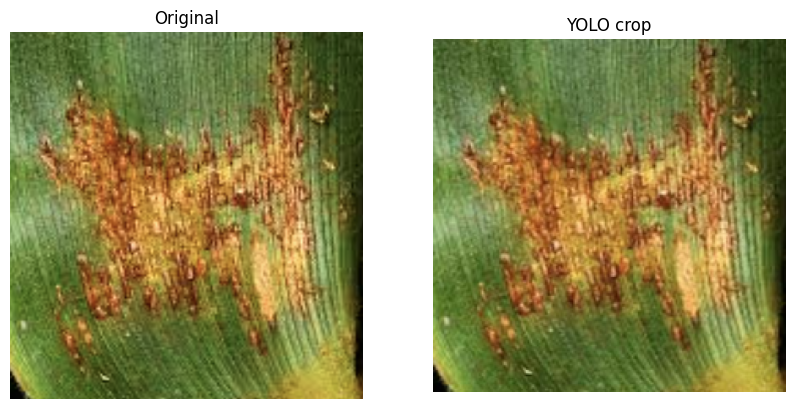

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Prediction: not_corn_leaf
Confidence: 0.8133

All probabilities:
blight         : 0.0030
common_rust    : 0.1834
gray_spot      : 0.0003
healthy        : 0.0000
not_corn_leaf  : 0.8133


In [33]:
# Run this cell after choosing an image above.

uploaded = uploader.value[0]

img = Image.open(io.BytesIO(uploaded["content"])).convert("RGB")

temp_path = "/kaggle/working/temp_upload_image.jpg"
img.save(temp_path)

cropped = crop_with_yolo(
    image_path=temp_path,
    yolo_model=yolo_model,
    conf_thres=0.25,
    img_size=IMG_SIZE
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cropped)
plt.title("YOLO crop")
plt.axis("off")

plt.show()

x = np.array(cropped).astype("float32") / 255.0
x = np.expand_dims(x, axis=0)

pred = model.predict(x)[0]

pred_idx = int(np.argmax(pred))
confidence = float(pred[pred_idx])

print("Prediction:", CLASS_NAMES[pred_idx])
print("Confidence:", f"{confidence:.4f}")

print("\nAll probabilities:")
for cls, prob in zip(CLASS_NAMES, pred):
    print(f"{cls:15s}: {prob:.4f}")